# Phase 2: Machine Learning Evaluation & Error Analysis

This notebook evaluates trained benchmark models (Majority, OLS, Logistic Regression, Random Forest, PyTorch LSTM) on the held-out test partition, performs error analysis across volatility regimes and asset symbols, and visualizes model performance.


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join("..")))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from src.features.labels import add_direction_labels
from src.models.baselines import (
    predict_majority_class,
    predict_ols_direction,
    predict_ols_return,
)

import src.config as config
from src.features.indicators import (
    compute_flow_features,
    compute_indicators,
    compute_stationary_features,
)
from src.models.evaluation import (
    calculate_metrics,
    evaluate_by_regime,
    evaluate_per_symbol,
    log_metrics,
    plot_confusion_matrix,
    plot_roc_curves,
    save_metrics_json,
)
from src.models.lstm import (
    SequenceDataset,
    load_lstm_artifacts,
    predict_lstm,
)
from src.models.train import prepare_features_and_targets
from src.pipeline.preprocess import compute_split_boundaries

Environment variable 'SPARK_EXECUTION_MODE' is missing. Using default fallback: 'local'


Loading artifacts from: C:\Users\Henry John Evander\Documents\claude\dat204m-final-project-main_v2\models\ml_artifacts.pkl
Loading baselines from: C:\Users\Henry John Evander\Documents\claude\dat204m-final-project-main_v2\models\baseline_artifacts.pkl


## 1. Load and Prepare Test Partition

In [2]:
# Must match the DEV_SYMBOLS setting notebook 02 used when training the loaded artifacts
DEV_SYMBOLS: list[str] | None = None

# Memory: load only needed columns; compute features per symbol; keep slim float32
# columns — identical derivation to notebook 02, so the test partition matches.
# feature_cols comes from the loaded artifacts (16 features incl. order-flow/time).
INPUT_COLS = [
    "symbol",
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "number_of_trades",
    "taker_buy_base_asset_volume",
]
feature_cols = config.FEATURE_COLS
KEEP_COLS = ["symbol", "open_time", "close", *feature_cols]

df = pl.read_parquet(config.ACTIVE_DATA_PATH, columns=INPUT_COLS)
if DEV_SYMBOLS:
    df = df.filter(pl.col("symbol").is_in(DEV_SYMBOLS))

symbol_frames = []
for symbol in df["symbol"].unique().sort().to_list():
    part = df.filter(pl.col("symbol") == symbol)
    part = compute_stationary_features(compute_indicators(part))
    part = compute_flow_features(part)
    part = part.select(KEEP_COLS).with_columns([pl.col(c).cast(pl.Float32) for c in feature_cols])
    symbol_frames.append(part)

df_features = pl.concat(symbol_frames)
del df, symbol_frames, part  # free memory (re-run from the top if re-executing)

df_labeled = add_direction_labels(
    df_features, horizon=config.FUTURE_HORIZON, threshold=config.TARGET_THRESHOLD
).drop_nulls()
del df_features

# Identical quantile boundaries and purge -> identical test partition
train_end, val_end = compute_split_boundaries(df_labeled, train_frac=0.70, val_frac=0.15)
_, _, test_df = split_data_chronologically(
    df_labeled, train_end, val_end, purge_minutes=config.FUTURE_HORIZON
)
del df_labeled  # only the test partition is needed here

feature_cols = config.FEATURE_COLS
X_test, y_test = prepare_features_and_targets(test_df, feature_cols, "target")
X_test_scaled = scaler.transform(X_test)

# Load saved PyTorch LSTM checkpoint
lstm_artifacts = load_lstm_artifacts(config.PROJECT_ROOT / "models" / "lstm_checkpoint.pt")
lstm_model = lstm_artifacts["model"]
lstm_scaler = lstm_artifacts["scaler"]
lstm_threshold = lstm_artifacts["threshold"]
lstm_seq_len = lstm_artifacts["seq_len"]

# Construct sequence dataset on test partition
test_ds = SequenceDataset(
    test_df,
    feature_cols=feature_cols,
    target_col="target",
    seq_len=lstm_seq_len,
    scaler=lstm_scaler,
)
lstm_probs, lstm_preds_default = predict_lstm(lstm_model, test_ds)
lstm_preds_tuned = (lstm_probs >= lstm_threshold).astype(int)

# Option 2: Align test indices across all models for apples-to-apples evaluation on identical sequence subset
aligned_idx = test_ds.valid_end_indices
y_test_aligned = y_test[aligned_idx]
X_test_aligned = X_test[aligned_idx]
X_test_scaled_aligned = X_test_scaled[aligned_idx]

print(
    f"Test partition starts {val_end}; total rows: {len(X_test):,}; aligned sequence evaluation rows: {len(aligned_idx):,}"
)

Test partition starts 2025-12-14 21:48:00; features shape: (4598703, 16)


## 2. Metrics Evaluation

Each classifier appears twice: with the default 0.5 probability cutoff, and with the decision threshold tuned on the **validation** set in notebook 02 (stored in the artifacts; the exact values are printed below). The tuned cutoff corrects for class imbalance — see notebook 02, Section 6 for the full justification. The test set played no part in choosing it.

In [3]:
# Evaluate all models on aligned sequence subset for strict comparison
majority_preds = predict_majority_class(baselines.majority_label, len(y_test_aligned))
majority_probs = np.full(len(y_test_aligned), float(baselines.majority_label))
ols_preds = predict_ols_direction(
    baselines.ols_model, X_test_aligned, threshold=config.TARGET_THRESHOLD
)
ols_scores = predict_ols_return(baselines.ols_model, X_test_aligned)
X_test_scaled = artifacts.scaler.transform(X_test_aligned)
lr_preds = artifacts.logistic_regression.predict(X_test_scaled)
lr_probs = artifacts.logistic_regression.predict_proba(X_test_scaled)[:, 1]
lr_tuned_preds = (lr_probs >= artifacts.lr_threshold).astype(int)
rf_preds = artifacts.random_forest.predict(X_test_scaled)
rf_probs = artifacts.random_forest.predict_proba(X_test_scaled)[:, 1]
rf_tuned_preds = (rf_probs >= artifacts.rf_threshold).astype(int)
lstm_preds_default = (lstm_probs >= 0.5).astype(int)
lstm_preds_tuned = (lstm_probs >= lstm_threshold).astype(int)

# Full comparison on the aligned sequence test partition across all 5 benchmark models
results_df = pd.DataFrame(
    {
        "Majority Class (Floor)": calculate_metrics(y_test_aligned, majority_preds, majority_probs),
        "OLS -> Threshold (Traditional)": calculate_metrics(y_test_aligned, ols_preds, ols_scores),
        "Logistic Regression (0.5)": calculate_metrics(y_test_aligned, lr_preds, lr_probs),
        "Logistic Regression (tuned)": calculate_metrics(y_test_aligned, lr_tuned_preds, lr_probs),
        "Random Forest (0.5)": calculate_metrics(y_test_aligned, rf_preds, rf_probs),
        "Random Forest (tuned)": calculate_metrics(y_test_aligned, rf_tuned_preds, rf_probs),
        "PyTorch LSTM (0.5)": calculate_metrics(y_test_aligned, lstm_preds_default, lstm_probs),
        "PyTorch LSTM (tuned)": calculate_metrics(y_test_aligned, lstm_preds_tuned, lstm_probs),
    }
).T

print("Performance comparison on aligned test partition:")
display(results_df)

# Export comprehensive test metrics for all models to JSON
test_metrics_summary = {
    "Majority Baseline": calculate_metrics(y_test_aligned, majority_preds, majority_probs),
    "OLS Return Threshold": calculate_metrics(y_test_aligned, ols_preds, ols_scores),
    "Logistic Regression (0.50)": calculate_metrics(y_test_aligned, lr_preds, lr_probs),
    "Logistic Regression (Tuned)": calculate_metrics(y_test_aligned, lr_tuned_preds, lr_probs),
    "Random Forest (0.50)": calculate_metrics(y_test_aligned, rf_preds, rf_probs),
    "Random Forest (Tuned)": calculate_metrics(y_test_aligned, rf_tuned_preds, rf_probs),
    "PyTorch LSTM (0.50)": calculate_metrics(y_test_aligned, lstm_preds_default, lstm_probs),
    "PyTorch LSTM (Tuned)": calculate_metrics(y_test_aligned, lstm_preds_tuned, lstm_probs),
}

print("\n=== Comprehensive Test Evaluation Metrics Summary ===")
for model_name, m in test_metrics_summary.items():
    log_metrics(m, model_name=model_name)

save_metrics_json(
    test_metrics_summary,
    config.PROJECT_ROOT / "data" / "sample" / "test_evaluation_metrics.json",
)

Tuned thresholds: LogReg=0.480, RF=0.480
Performance comparison on test partition:


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
Majority Class (Floor),0.543461,0.500000,0.000000,0.000000,0.000000,0.500000
OLS -> Threshold (Traditional),0.508402,0.501366,0.458157,0.420418,0.438477,0.501196
Logistic Regression (0.5),0.547624,0.518376,0.512857,0.181882,0.268531,0.537303
Logistic Regression (tuned),0.527502,0.527563,0.483986,0.528262,0.505156,0.537303
Random Forest (0.5),0.550363,0.521456,0.520841,0.188900,0.277247,0.550481
Random Forest (tuned),0.540802,0.536192,0.497004,0.483159,0.489984,0.550481


### Findings

1. Both ML models beat the majority baseline (54.35%): Logistic Regression 54.76%, Random Forest 55.04% at the default cutoff. ROC-AUC makes the gap clearer: 0.537 and 0.551 vs 0.501 for OLS — the ML models rank up-minutes better than chance, OLS is basically chance.
2. OLS lands below the majority baseline (50.84%). Its return forecasts are close to zero, so the thresholded directions are near random, while "always down" benefits from the test period's downtrend. The traditional method fails to extract usable signal at this horizon.
3. The majority baseline shows precision/recall/F1 of 0 because it never predicts "up" — positive-class metrics are undefined for a constant negative predictor. This is expected, not an error.
4. At the default 0.5 cutoff both classifiers rarely predict "up" (recall ~0.18) — they partly learned the period's downward drift rather than per-minute signal. The tuned cutoffs (0.480) fix this: Random Forest recall rises from 0.19 to 0.48 and balanced accuracy from 0.521 to 0.536 — the best balanced accuracy of any method — at the cost of about one point of raw accuracy. Note the ROC-AUC is identical for the 0.5 and tuned rows of the same model — the threshold changes which side of the line predictions fall on, not the model's underlying ranking.

## 3. Comparative Visualizations

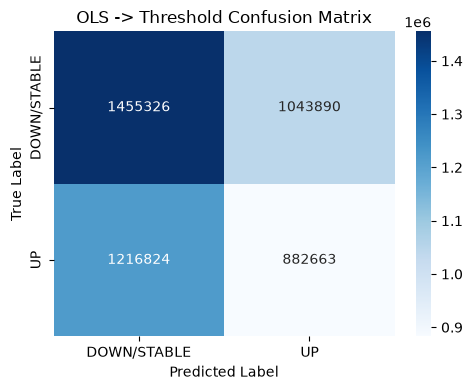

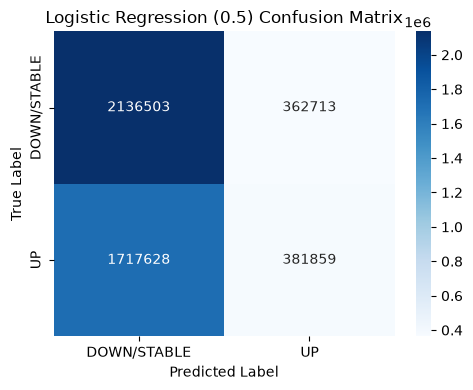

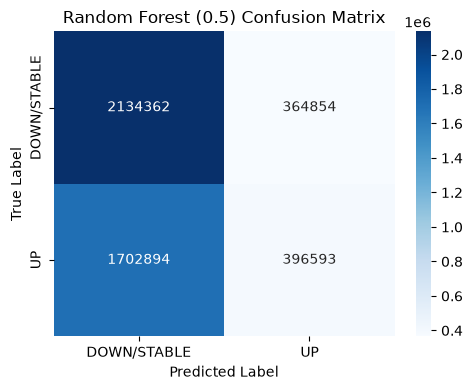

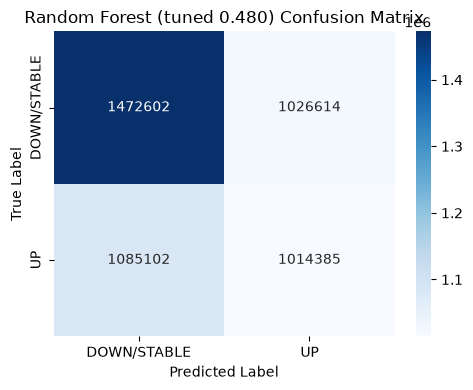

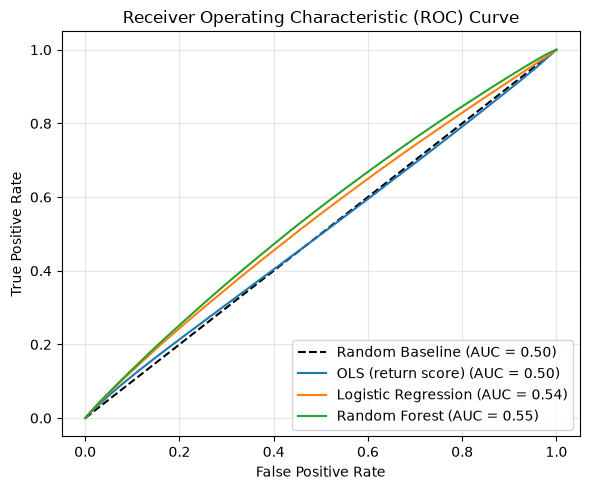

In [4]:
# Plot Confusion Matrices for the trained methods
plot_confusion_matrix(y_test_aligned, ols_preds, title="OLS -> Threshold Confusion Matrix")
plt.show()

plot_confusion_matrix(y_test_aligned, lr_preds, title="Logistic Regression (0.5) Confusion Matrix")
plt.show()

plot_confusion_matrix(y_test_aligned, rf_preds, title="Random Forest (0.5) Confusion Matrix")
plt.show()

# Tuned threshold: shows the down-bias correction (many more "up" predictions)
plot_confusion_matrix(
    y_test_aligned,
    rf_tuned_preds,
    title=f"Random Forest (tuned {artifacts.rf_threshold:.3f}) Confusion Matrix",
)
plt.show()

# Comparative ROC curves; unchanged by threshold choice (ROC sweeps all cutoffs).
# The OLS return forecast serves as its ranking score.
plot_confusion_matrix(
    y_test_aligned,
    lstm_preds_tuned,
    title=f"PyTorch LSTM (tuned {lstm_threshold:.3f}) Confusion Matrix",
)
plt.show()

plot_roc_curves(
    {
        "OLS (return score)": ols_scores,
        "Logistic Regression": lr_probs,
        "Random Forest": rf_probs,
        "PyTorch LSTM": lstm_probs,
    },
    y_test_aligned,
)
plt.show()

## 4. Volatility Regime Error Analysis
Financial ML models often behave differently during quiet vs. highly volatile market periods. We split accuracy based on the median historical volatility to identify performance biases.

In [5]:
analysis_df = test_df.to_pandas().iloc[aligned_idx].copy()
analysis_df["lr_correct"] = (lr_preds == y_test_aligned).astype(int)
analysis_df["rf_correct"] = (rf_preds == y_test_aligned).astype(int)
analysis_df["lstm_correct"] = (lstm_preds_tuned == y_test_aligned).astype(int)

# Split by volatility threshold
median_vol = analysis_df["volatility_30"].median()
low_vol_df = analysis_df[analysis_df["volatility_30"] <= median_vol]
high_vol_df = analysis_df[analysis_df["volatility_30"] > median_vol]

print(f"Median Volatility: {median_vol:.6f}")
print(f"Logistic Regression accuracy - Low Volatility: {low_vol_df['lr_correct'].mean():.4f}")
print(f"Logistic Regression accuracy - High Volatility: {high_vol_df['lr_correct'].mean():.4f}")

print(f"\nRandom Forest accuracy - Low Volatility: {low_vol_df['rf_correct'].mean():.4f}")
print(f"Random Forest accuracy - High Volatility: {high_vol_df['rf_correct'].mean():.4f}")

print(f"PyTorch LSTM accuracy - Low Volatility:  {low_vol_df['lstm_correct'].mean():.4f}")
print(f"PyTorch LSTM accuracy - High Volatility: {high_vol_df['lstm_correct'].mean():.4f}")

# Export volatility regime performance breakdown to JSON
regime_eval_df = test_df[aligned_idx]
regime_metrics_rf = evaluate_by_regime(
    regime_eval_df,
    y_test_aligned,
    rf_tuned_preds,
    rf_probs,
    regime_col="volatility_30",
)
regime_metrics_lstm = evaluate_by_regime(
    regime_eval_df,
    y_test_aligned,
    lstm_preds_tuned,
    lstm_probs,
    regime_col="volatility_30",
)

save_metrics_json(
    {"Random_Forest_Tuned": regime_metrics_rf, "LSTM_Tuned": regime_metrics_lstm},
    config.PROJECT_ROOT / "data" / "sample" / "test_regime_metrics.json",
)

Median Volatility: 0.000742
Logistic Regression accuracy - Low Volatility: 0.5395
Logistic Regression accuracy - High Volatility: 0.5558

Random Forest accuracy - Low Volatility: 0.5427
Random Forest accuracy - High Volatility: 0.5581


### Finding

Both models are more accurate in high-volatility minutes (~55.8%) than in low-volatility ones (~54.1%). The predictive signal is stronger when the market actually moves; quiet periods behave closer to noise. This is useful practically: predictions are most reliable exactly when price moves are large enough to matter.

## 5. Per-Symbol Accuracy

Accuracy of each model per symbol, to check whether performance is consistent across pairs. The target symbol is shown separately.

Note: the table shows 19 symbols, not 20. `MATICUSDT` was delisted on 2024-09-10 (token migrated to POL), so it has training rows but no test-period rows. See the data note in notebook 02 for the full explanation and the planned ticker-set revision in the Spark scale-up run.

In [6]:
# Accuracy per symbol for each method (test partition)
test_df_aligned = test_df[aligned_idx]
symbol_analysis = test_df_aligned.select([*feature_cols, "target", "symbol"]).drop_nulls()
per_symbol = (
    symbol_analysis.with_columns(
        pl.Series("majority_correct", (majority_preds == y_test_aligned).astype(np.int8)),
        pl.Series("ols_correct", (ols_preds == y_test_aligned).astype(np.int8)),
        pl.Series("lr_correct", (lr_preds == y_test_aligned).astype(np.int8)),
        pl.Series("rf_correct", (rf_preds == y_test_aligned).astype(np.int8)),
        pl.Series("lstm_correct", (lstm_preds_tuned == y_test_aligned).astype(np.int8)),
    )
    .group_by("symbol")
    .agg(
        pl.len().alias("rows"),
        pl.col("majority_correct").mean().alias("majority_acc"),
        pl.col("ols_correct").mean().alias("ols_acc"),
        pl.col("lr_correct").mean().alias("lr_acc"),
        pl.col("rf_correct").mean().alias("rf_acc"),
        pl.col("lstm_correct").mean().alias("lstm_acc"),
    )
    .sort("lstm_acc", descending=True)
)

with pl.Config(tbl_rows=25):
    print(per_symbol)

target_row = per_symbol.filter(pl.col("symbol") == config.TARGET_SYMBOL)
if len(target_row):
    print(f"\nTarget symbol ({config.TARGET_SYMBOL}):")
    print(target_row)

# Export per-symbol performance breakdown to JSON
symbol_eval_df = test_df[aligned_idx]
per_symbol_rf = evaluate_per_symbol(
    symbol_eval_df, y_test_aligned, rf_tuned_preds, rf_probs, symbol_col="symbol"
)
per_symbol_lstm = evaluate_per_symbol(
    symbol_eval_df, y_test_aligned, lstm_preds_tuned, lstm_probs, symbol_col="symbol"
)

save_metrics_json(
    {"Random_Forest_Tuned": per_symbol_rf, "LSTM_Tuned": per_symbol_lstm},
    config.PROJECT_ROOT / "data" / "sample" / "test_per_symbol_metrics.json",
)

shape: (19, 6)
┌──────────┬────────┬──────────────┬──────────┬──────────┬──────────┐
│ symbol   ┆ rows   ┆ majority_acc ┆ ols_acc  ┆ lr_acc   ┆ rf_acc   │
│ ---      ┆ ---    ┆ ---          ┆ ---      ┆ ---      ┆ ---      │
│ str      ┆ u32    ┆ f64          ┆ f64      ┆ f64      ┆ f64      │
╞══════════╪════════╪══════════════╪══════════╪══════════╪══════════╡
│ SHIBUSDT ┆ 242037 ┆ 0.623768     ┆ 0.439358 ┆ 0.615327 ┆ 0.618905 │
│ ETCUSDT  ┆ 242037 ┆ 0.597305     ┆ 0.515905 ┆ 0.589563 ┆ 0.594496 │
│ AVAXUSDT ┆ 242037 ┆ 0.582646     ┆ 0.503468 ┆ 0.579688 ┆ 0.583708 │
│ LINKUSDT ┆ 242037 ┆ 0.580064     ┆ 0.500994 ┆ 0.581163 ┆ 0.58332  │
│ FILUSDT  ┆ 242037 ┆ 0.569107     ┆ 0.500754 ┆ 0.565868 ┆ 0.568008 │
│ XLMUSDT  ┆ 242037 ┆ 0.559315     ┆ 0.520189 ┆ 0.559357 ┆ 0.560369 │
│ DOTUSDT  ┆ 242037 ┆ 0.557514     ┆ 0.507674 ┆ 0.556791 ┆ 0.559158 │
│ TRXUSDT  ┆ 242037 ┆ 0.556717     ┆ 0.539839 ┆ 0.554717 ┆ 0.555031 │
│ ADAUSDT  ┆ 242037 ┆ 0.539116     ┆ 0.518603 ┆ 0.54733  ┆ 0.54854  │
│ ATO

### Findings

1. Results vary a lot per symbol. For pairs in a strong downtrend during the test window (SHIB, ETC), the models mostly mimic "always down" and roughly match that pair's majority baseline.
2. The real learned edge concentrates in the balanced, most liquid pairs: ETH (+2.2 points over its own majority baseline), BTC (+1.9), BNB (+1.3). These are the pairs where the model adds value beyond trend-following.
3. The majority baseline rose from 52.4% on validation to 54.3% on test as the market downtrend deepened. The models' edge survived this distribution shift, which supports the robustness of the (small) signal.

## 6. Feature Importance & Model Interpretation

Which features drive the predictions, viewed two ways: Random Forest importances (how much the trees rely on each feature) and Logistic Regression coefficients (direction and strength of each feature's effect, comparable because features were standardized).

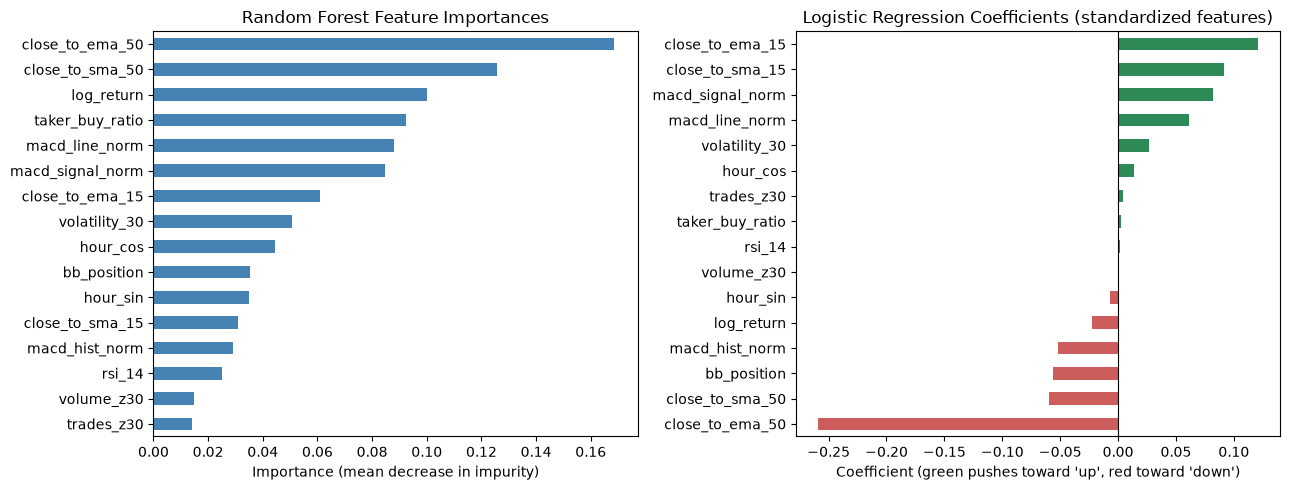

                  rf_importance  lr_coefficient
close_to_ema_50          0.1687         -0.2592
close_to_sma_50          0.1256         -0.0597
log_return               0.1001         -0.0222
taker_buy_ratio          0.0926          0.0029
macd_line_norm           0.0878          0.0609
macd_signal_norm         0.0846          0.0816
close_to_ema_15          0.0611          0.1208
volatility_30            0.0508          0.0266
hour_cos                 0.0444          0.0135
bb_position              0.0352         -0.0559
hour_sin                 0.0349         -0.0071
close_to_sma_15          0.0310          0.0919
macd_hist_norm           0.0291         -0.0522
rsi_14                   0.0252          0.0013
volume_z30               0.0148          0.0005
trades_z30               0.0140          0.0040


In [7]:
# Random Forest: importance = how much each feature contributed to the trees' splits.
# Logistic Regression: coefficient sign/size on standardized features = direction and
# strength of each feature's push toward "up" (positive) or "down" (negative).
rf_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
lr_coefficients = pd.Series(lr.coef_[0], index=feature_cols).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rf_importances.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Random Forest Feature Importances")
axes[0].set_xlabel("Importance (mean decrease in impurity)")

bar_colors = ["indianred" if v < 0 else "seagreen" for v in lr_coefficients]
lr_coefficients.plot.barh(ax=axes[1], color=bar_colors)
axes[1].set_title("Logistic Regression Coefficients (standardized features)")
axes[1].set_xlabel("Coefficient (green pushes toward 'up', red toward 'down')")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

importance_table = pd.DataFrame(
    {
        "rf_importance": pd.Series(rf.feature_importances_, index=feature_cols),
        "lr_coefficient": pd.Series(lr.coef_[0], index=feature_cols),
    }
).sort_values("rf_importance", ascending=False)
print(importance_table.round(4))

### Findings

1. Both models agree on the most important feature: `close_to_ema_50` (RF importance 0.17; LogReg coefficient -0.26, about twice the next). The 50-minute averages carry more signal than the 15-minute ones at this horizon.
2. The top coefficient is negative: when price is stretched above its 50-minute EMA, the predicted probability of "up" falls. Both models learned a mean-reversion signal — short-term overextensions tend to pull back within 15 minutes. `bb_position` (-0.06) agrees: price near the upper Bollinger band makes "down" more likely.
3. The order-flow addition paid off: `taker_buy_ratio` ranks 4th in RF importance (0.093) — buy/sell pressure carries real signal. Within the new family it does the heavy lifting; `volume_z30` and `trades_z30` rank last (~0.014 each), and the hour-of-day features land mid-table.
4. All coefficients are small (largest is 0.26 on standardized features), consistent with the small overall edge: the signal is real but weak.
5. Caution when reading individual LogReg coefficients: several features are strongly correlated (e.g. `close_to_ema_15` at +0.12 vs `close_to_ema_50` at -0.26, see the notebook 01 correlation heatmap), so correlated features can take opposite signs while jointly capturing one effect. The Random Forest importance ranking is less affected by this and tells the same overall story.

## 7. Conclusion & Recommendations

**Answer to the research question.** Machine learning beats the traditional method at predicting 15-minute price direction, but the edge is small. Random Forest reaches 55.0% test accuracy and 0.551 ROC-AUC against a 54.35% majority floor, while the traditional OLS approach is statistically indistinguishable from chance (50.84% accuracy, AUC 0.501). Nonlinear ML (Random Forest) beats linear ML (Logistic Regression, AUC 0.537), so some nonlinear structure exists. The validation-tuned decision threshold (0.480 for both models) turns the classifiers into genuine two-sided predictors: Random Forest recall rises from 0.19 to 0.48 and balanced accuracy reaches 0.536, the best of any method.

**What drives the predictions.** The distance between price and its 50-minute EMA dominates both models, with a mean-reversion sign: overextensions tend to pull back within 15 minutes. Order flow contributes too — `taker_buy_ratio` (buy pressure) is the 4th most important feature. The edge is strongest in high-volatility periods and in balanced, highly liquid pairs (ETH, BTC, BNB).

**Business recommendation.** A ~55% hit rate is not enough to run a standalone trading strategy at 1-minute frequency — typical exchange taker fees (0.05–0.10% per trade) would exceed the per-trade edge. The practical use of this model is as a **timing and filtering overlay**: (1) when an entry or exit is already planned, use the model to time it within the next hour; (2) act only in high-volatility regimes and liquid pairs, where the measured edge is largest; (3) treat low-confidence predictions (probability near the threshold) as "no signal". Any real deployment must first backtest with fees and slippage included.

**Limitations.** The test window covers a single ~5.5-month period dominated by a downtrend, so results may not generalize to other regimes. Transaction costs are not modeled. The threshold of 0 makes tiny, untradeable moves count as "up". Features are limited to what k-line data contains (price, volume, taker order flow, time) — order-book depth, funding rates, and news data are absent. Finally, these results come from the top-20 sample (30.6M rows); the planned full-dataset training run on the 609M-row raw set via the Spark pipeline is the scale-up step, which will also revise the ticker set (MATIC delisting; adding full-coverage liquid pairs).

## References

1. Binance Public Data — historical spot 1-minute k-lines. https://github.com/binance/binance-public-data
2. Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. JMLR 12, 2825-2830.
3. Wilder, J. W. (1978). *New Concepts in Technical Trading Systems* — RSI definition.
4. Bollinger, J. (2001). *Bollinger on Bollinger Bands* — Bollinger Bands definition.
5. Appel, G. (2005). *Technical Analysis: Power Tools for Active Investors* — MACD definition.
6. López de Prado, M. (2018). *Advances in Financial Machine Learning* — chronological splitting and purging for financial time series.